In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 200)
FIG = ROOT / 'reports' / 'figures'
FIG.mkdir(parents=True, exist_ok=True)

# Phase 2 — Text preprocessing and normalization

Computed by `python -m src.preprocess`; this notebook shows the results.

## 1. Before / after: 20 examples (10 with a quantity, 10 random)

In [2]:
bb = pd.read_parquet(ROOT/'data'/'processed'/'bigbasket_pre.parquet')
fk = pd.read_parquet(ROOT/'data'/'processed'/'flipkart_pre.parquet')
both = pd.concat([bb, fk], ignore_index=True)
cols = ['source', 'product_name', 'name_clean', 'name_norm', 'qty_value', 'qty_unit', 'pack_count']
with_q = both[both['qty_value'].notna() | both['pack_count'].notna()].sample(10, random_state=42)
rand = both.drop(with_q.index).sample(10, random_state=42)
examples = pd.concat([with_q, rand])[cols]
examples.to_csv(ROOT/'reports'/'phase2_before_after.csv', index=False)
examples

,source,product_name,name_clean,name_norm,qty_value,qty_unit,pack_count
18568,bigbasket,Elegance Deodorizing Talc - For Men 250 g + Gentleman Talc - For Men 250 g,elegance deodorizing talc for men 250 g gentleman talc for men 250 g,elegance deodorize talc for man 250 g gentleman talc for man 250 g,250.000,g,NaN
40378,flipkart,Bracevor Laptop Case for Apple Macbook Air 13.3 inch,bracevor laptop case for apple macbook air 33.782 cm,bracevor laptop case for apple macbook air 33.782 cm,33.782,cm,NaN
20922,bigbasket,Safewash Liquid Detergent 1kg (B1G1) + Softouch 2X Fabric Conditioner 800ml,safewash liquid detergent 1000 g b 1 g 1 softouch 2 x fabric conditioner 800 ml,safewash liquid detergent 1000 g b 1 g 1 softouch 2 x fabric conditioner 800 ml,1000.000,g,2.0
32493,flipkart,Dailyware Kadhai 1.5 L,dailyware kadhai 1500 ml,dailyware kadhai 1500 ml,1500.000,ml,NaN
33083,flipkart,Desert Eshop Real Antique Brass Royal 3 Minute Sand Timer 281 Showpiece - ...,desert eshop real antique brass royal 3 minute sand timer 281 showpiece 7 cm,desert eshop real antique brass royal 3 minute sand timer 281 showpiece 7 cm,7.000,cm,NaN
26681,bigbasket,Paper Napkins - Velwet Tissue (12 x 12),paper napkins velwet tissue 12 x 12,paper napkin velwet tissue 12 x 12,NaN,NaN,12.0
32415,flipkart,Shoppingtara Amabari Marble Plate Showpiece - 7 cm,shoppingtara amabari marble plate showpiece 7 cm,shoppingtara amabari marble plate showpiece 7 cm,7.000,cm,NaN
1207,bigbasket,"Basmati Rice - Mogra, Broken/Tukda 5 Kg + Wheat Flour (Chakki Atta) 5 Kg",basmati rice mogra broken tukda 5000 g wheat flour chakki atta 5000 g,basmati rice mogra broken tukda 5000 g wheat flour chakki atta 5000 g,5000.000,g,NaN
43113,flipkart,Gee Power Imported Set of 2 Swimming Goggles,gee power imported set of 2 swimming goggles,gee power import set of 2 swimming goggle,NaN,NaN,2.0
20125,bigbasket,20g Whey Protein Bar - Cranberry Orange,20 g whey protein bar cranberry orange,20 g whey protein bar cranberry orange,20.000,g,NaN


## 2. Unit normalization vs WDC-PAVE normalized values (exact match)

In [3]:
acc = pd.read_csv(ROOT/'reports'/'phase2_unit_accuracy.csv', index_col=0); acc

,n,no_normalization,first_number_only,ours_parsed_only,ours
Cache,31,0.000,0.000,0.935,0.935
Capacity,68,0.765,0.015,0.235,0.985
Depth,47,0.000,0.000,1.000,1.000
Height,101,0.020,0.000,0.980,1.000
Length,52,0.000,0.000,0.962,0.962
Pack Quantity,64,0.047,0.938,0.969,0.969
Paper Weight,7,0.000,0.000,1.000,1.000
Rotational Speed,65,0.000,0.000,1.000,1.000
Size/Weight,22,0.136,0.000,0.864,1.000
Width,140,0.000,0.000,1.000,1.000


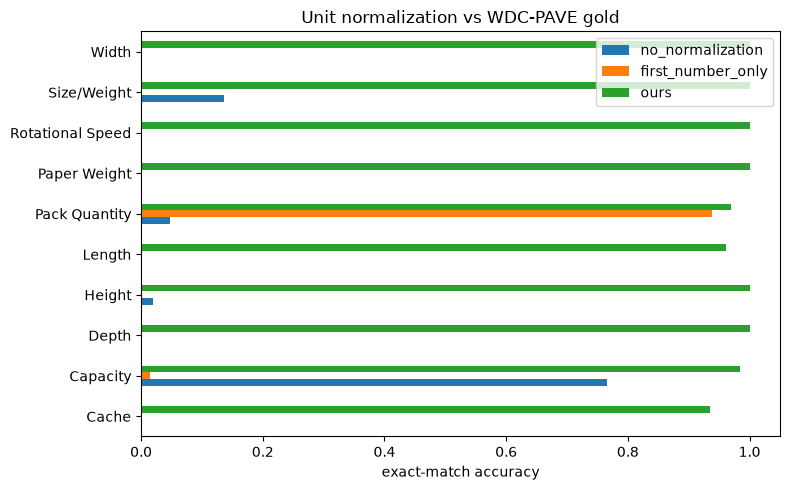

In [4]:
ax = acc.drop('ALL')[['no_normalization', 'first_number_only', 'ours']].plot.barh(figsize=(8, 5))
ax.set_xlabel('exact-match accuracy'); ax.set_title('Unit normalization vs WDC-PAVE gold')
plt.tight_layout(); plt.savefig(FIG/'phase2_units.png', dpi=120)

In [5]:
pairs = pd.read_csv(ROOT/'reports'/'phase2_unit_pairs.csv')
pairs[~pairs['ok_ours']][['attribute', 'raw', 'gold', 'ours']]

,attribute,raw,gold,ours
137,Cache,512,512 Megabytes,512
180,Capacity,400GB Native/800GB Compressed,400GB Native/800GB Compressed,400 Gigabytes
184,Length,"109"" - 120""",304.8,276.9
214,Pack Quantity,Five dividers per pack,5,Five dividers per pack
241,Pack Quantity,trio,3,trio
279,Length,"54"" - 62""",157.5,137.2
462,Cache,256,256 Megabytes,256


## 3. Spelling correction (SymSpell, dictionary from our own vocabulary)

In [6]:
pd.read_json(ROOT/'reports'/'phase2_spelling.json').drop(columns='examples_rare_changed').set_index('setting').T

setting,unseen words only (system),also rare seen words
typo_words,487.000,487.000
restored,444.000,447.000
restored_rate,0.912,0.918
wrong_correction_rate,0.023,0.023
rare_tokens,7426.000,7426.000
rare_tokens_changed,0.000,1320.000
rare_changed_rate,0.000,0.178


In [7]:
pd.read_csv(ROOT/'reports'/'phase2_rare_changes_sample.csv')

,token,changed_to
0,wlking,walking
1,cleasing,cleaning
2,asafetida,asafoetida
3,indirang,indian
4,grainy,grain
5,frood,food
6,cubics,cubic
7,chocolat,chocolate
8,sprint,print
9,cells,cell


## 4. Abbreviation candidates mined from the corpus

In [8]:
pd.read_csv(ROOT/'reports'/'phase2_abbrev_candidates.csv').head(25)

,short,short_count,expansion,expansion_count
0,print,455,printed,1347
1,all,216,allure,473
2,choco,191,chocolate,687
3,stick,139,sticker,385
4,pen,98,pencil,359
5,deo,90,deodorant,460
6,eye,80,eyelet,165
7,dia,62,diamond,719
8,la,60,lavender,180
9,fab,59,fabric,222


## 5. Effect on duplicate detection: how many BigBasket names become identical after each step

In [9]:
steps = {'raw': bb['product_name'], 'lowercase+strip': bb['product_name'].str.lower().str.strip(),
         'normalize_text': bb['name_clean'], '+ abbreviations + spelling + lemmas': bb['name_norm']}
pd.DataFrame({k: [v.nunique(), int(v.duplicated().sum())] for k, v in steps.items()}, index=['distinct names', 'duplicates']).T

,distinct names,duplicates
raw,23540,4014
lowercase+strip,23511,4043
normalize_text,23299,4256
+ abbreviations + spelling + lemmas,23235,4320


## 6. Quantity coverage per source

In [10]:
rows = []
for n in ['bigbasket', 'flipkart', 'off_india', 'abt', 'buy']:
    d = pd.read_parquet(ROOT/'data'/'processed'/f'{n}_pre.parquet')
    rows.append({'source': n, 'rows': len(d), 'quantity found %': round(d['qty_value'].notna().mean()*100, 1),
                 'pack count found %': round(d['pack_count'].notna().mean()*100, 1),
                 'units': d['qty_unit'].value_counts().to_dict()})
pd.DataFrame(rows)

,source,rows,quantity found %,pack count found %,units
0,bigbasket,27555,3.9,1.1,"{'g': 553, 'cm': 279, 'ml': 246}"
1,flipkart,20000,5.3,0.9,"{'cm': 745, 'ml': 252, 'g': 65}"
2,off_india,21189,7.3,0.2,"{'g': 1165, 'ml': 374, 'cm': 2}"
3,abt,1081,3.0,0.7,"{'cm': 24, 'g': 7, 'ml': 1}"
4,buy,1092,3.6,2.3,"{'cm': 29, 'g': 8, 'ml': 2}"
